In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)



## Data exploration and preprocessing

In [2]:
df = pd.read_csv("Data/sleep_health.csv")

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

standardizing the column names

In [5]:
df.columns = (df.columns
              .str.strip()                    
              .str.lower()                     
              .str.replace(' ', '_')          
              .str.replace(r'[^\w\s]', '', regex=True)) 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   person_id                374 non-null    int64  
 1   gender                   374 non-null    object 
 2   age                      374 non-null    int64  
 3   occupation               374 non-null    object 
 4   sleep_duration           374 non-null    float64
 5   quality_of_sleep         374 non-null    int64  
 6   physical_activity_level  374 non-null    int64  
 7   stress_level             374 non-null    int64  
 8   bmi_category             374 non-null    object 
 9   blood_pressure           374 non-null    object 
 10  heart_rate               374 non-null    int64  
 11  daily_steps              374 non-null    int64  
 12  sleep_disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [7]:
df.describe()

,person_id,age,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,heart_rate,daily_steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [8]:
df.nunique()

person_id                  374
gender                       2
age                         31
occupation                  11
sleep_duration              27
quality_of_sleep             6
physical_activity_level     16
stress_level                 6
bmi_category                 4
blood_pressure              25
heart_rate                  19
daily_steps                 20
sleep_disorder               2
dtype: int64

In [9]:
df.isnull().sum()

person_id                    0
gender                       0
age                          0
occupation                   0
sleep_duration               0
quality_of_sleep             0
physical_activity_level      0
stress_level                 0
bmi_category                 0
blood_pressure               0
heart_rate                   0
daily_steps                  0
sleep_disorder             219
dtype: int64

In [10]:
df.duplicated().sum()

0

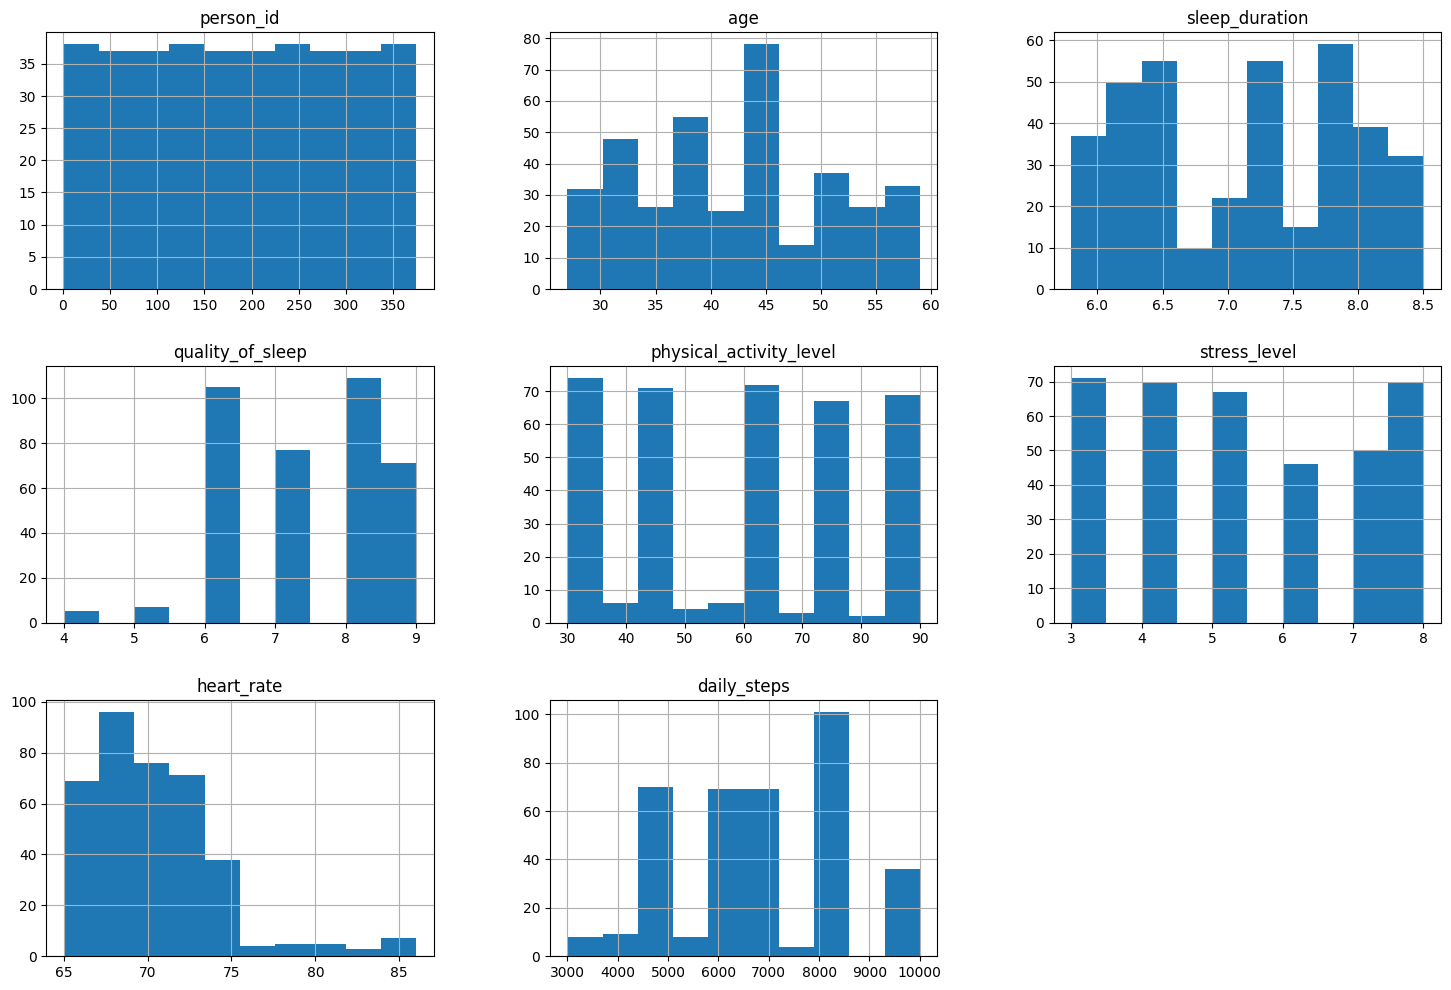

In [11]:
def column_dist():
    distribution = df.hist(figsize=(18,12))
    return distribution

column_dist();

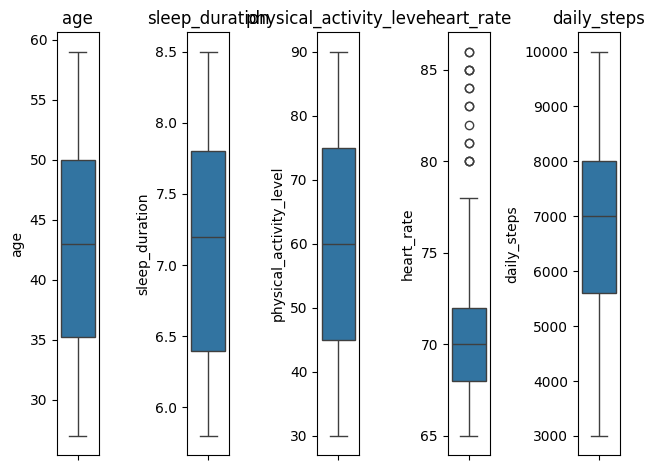

In [12]:
# Store the list of columns to plot
columns_to_plot = ['age', 'sleep_duration', 'physical_activity_level', 'heart_rate', 'daily_steps']

# Create the figure and two subplots
fig, axes = plt.subplots(ncols=len(columns_to_plot))

# Create the boxplot with Seaborn
for column, axis in zip(columns_to_plot, axes):
        sns.boxplot(data=df[column], ax=axis) 
        axis.set_title(column)
        # axis.set(xticklabels=[], xticks=[], ylabel=column)

# Show the plot
plt.tight_layout()
plt.show()


splitting the blood pressure into systolic and diastolic

In [13]:
# df['blood_pressure'].unique()

 # Spliting systolic and diastolic blood pressure
df[["systolic_bp", "diastolic_bp"]] = df["blood_pressure"].str.split("/", expand=True)

df["systolic_bp"] = df["systolic_bp"].astype(int)
df["diastolic_bp"] = df["diastolic_bp"].astype(int)

df.drop(columns=["blood_pressure"], inplace=True)


In [14]:
df['bmi_category'].unique()

array(['Overweight', 'Normal', 'Obese', 'Normal Weight'], dtype=object)

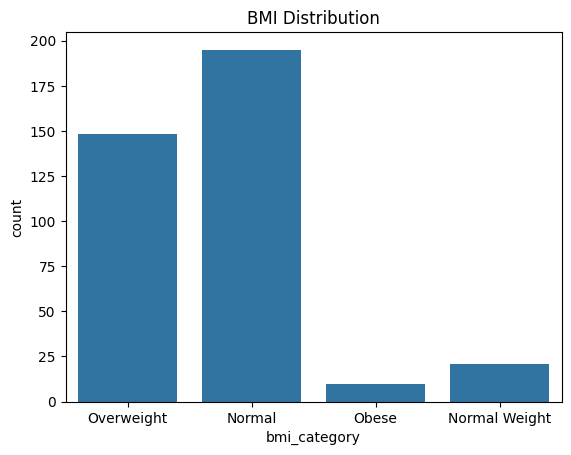

In [15]:
plt.figure()
sns.countplot(x="bmi_category", data=df)
plt.title("BMI Distribution")
plt.show()

Notice we have Normal and Normal weight at the same time. statiscallly checking if they are the same or different

comparing group summary stat

In [16]:
df.groupby("bmi_category").agg(
    count=("person_id", "count"),
    avg_age=("age", "mean"),
    avg_sleep_duration=("sleep_duration", "mean"),
    avg_sleep_quality=("quality_of_sleep", "mean"),
    avg_stress=("stress_level", "mean"),
    avg_heart_rate=("heart_rate", "mean"),
    avg_systolic_bp=("systolic_bp", "mean"),
    avg_diastolic_bp=("diastolic_bp", "mean")
)


,count,avg_age,avg_sleep_duration,avg_sleep_quality,avg_stress,avg_heart_rate,avg_systolic_bp,avg_diastolic_bp
bmi_category,,,,,,,,
Normal,195,38.482051,7.393846,7.661538,5.128205,68.728205,123.820513,80.666667
Normal Weight,21,38.380952,7.333333,7.428571,5.190476,71.285714,121.619048,80.000000
Obese,10,38.000000,6.960000,6.400000,5.700000,84.300000,139.200000,90.200000
Overweight,148,47.885135,6.770270,6.898649,5.729730,70.945946,135.054054,90.182432


sleep disorder dustribution comparison

In [17]:
pd.crosstab(df["bmi_category"], df["sleep_disorder"], normalize="index") * 100


sleep_disorder,Insomnia,Sleep Apnea
bmi_category,,
Normal,58.333333,41.666667
Normal Weight,50.000000,50.000000
Obese,40.000000,60.000000
Overweight,49.612403,50.387597


Test if Normal vs Normal Weight are statistically different

In [18]:
from scipy.stats import ttest_ind

normal = df[df["bmi_category"] == "Normal"]["quality_of_sleep"]
normal_weight = df[df["bmi_category"] == "Normal Weight"]["quality_of_sleep"];'f[rt5]'

ttest_ind(normal, normal_weight, nan_policy="omit")


TtestResult(statistic=1.0172112052956301, pvalue=0.310201600995037, df=214.0)

An inconsistency was observed in BMI category labels, where both “Normal” and “Normal Weight” appeared in the dataset despite representing identical classifications. A comparative analysis across demographic, sleep, and stress-related variables showed no statistically significant differences between the two groups (t-test, p = 0.31). Based on this evidence, the categories were group into a single “Normal” group to maintain analytical consistency and prevent artificial fragmentation.

In [19]:
# replacing Normal weight with Normal

df["bmi_category"] = df["bmi_category"].replace({
    "Normal Weight": "Normal"
})


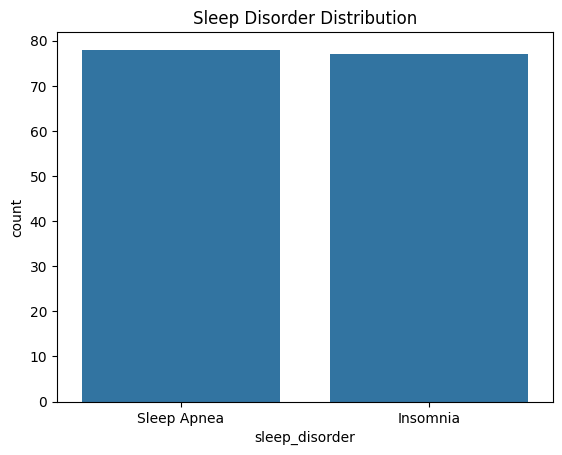

In [20]:
plt.figure()
sns.countplot(x="sleep_disorder", data=df)
plt.title("Sleep Disorder Distribution")
plt.show()

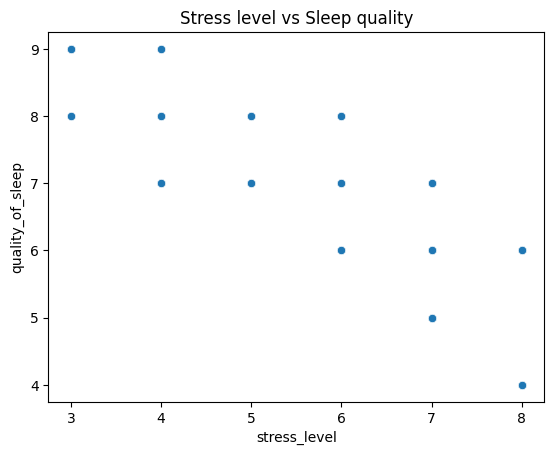

In [21]:
# stress and sleep correlation

plt.figure()
sns.scatterplot(
    x="stress_level",
    y="quality_of_sleep",
    data=df
)
plt.title("Stress level vs Sleep quality")
plt.show()


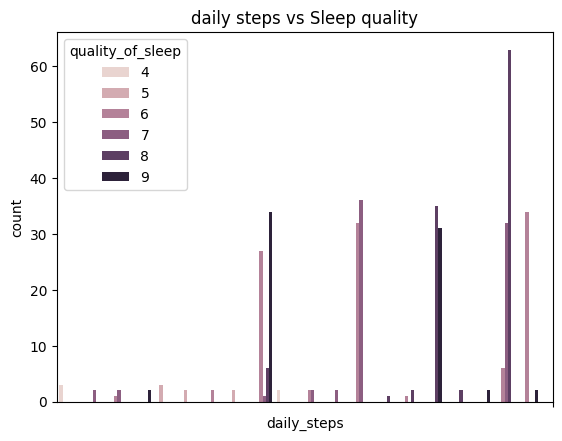

In [22]:
# daily steps and sleep quality

plt.figure()
sns.countplot(
    x="daily_steps",
    hue="quality_of_sleep",
    data=df
)

plt.xticks("")
plt.title("daily steps vs Sleep quality")
plt.show()

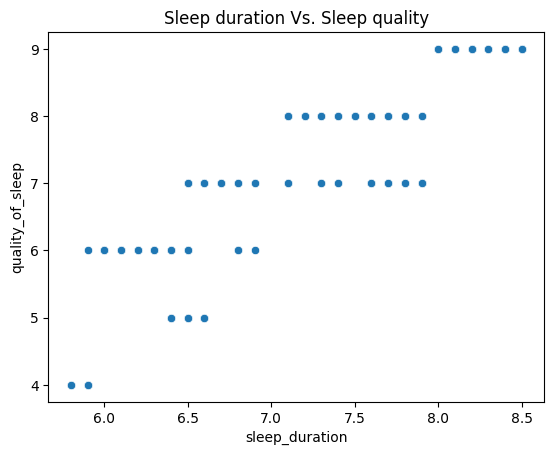

In [23]:
plt.figure()
sns.scatterplot(
    x="sleep_duration",
    y="quality_of_sleep",
    data=df
)
plt.title("Sleep duration Vs. Sleep quality")
plt.show()


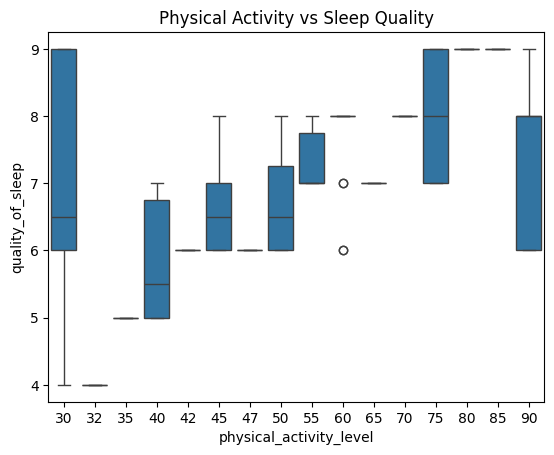

In [24]:
# phsical activitiy and sleep quality

plt.figure()
sns.boxplot(
    x="physical_activity_level",
    y="quality_of_sleep",
    data=df
)
plt.title("Physical Activity vs Sleep Quality")
plt.show()


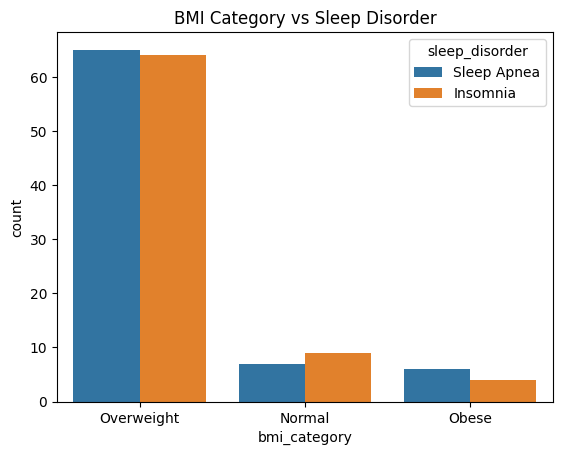

In [25]:
plt.figure()
sns.countplot(
    x="bmi_category",
    hue="sleep_disorder",
    data=df
)
plt.title("BMI Category vs Sleep Disorder")
plt.show()


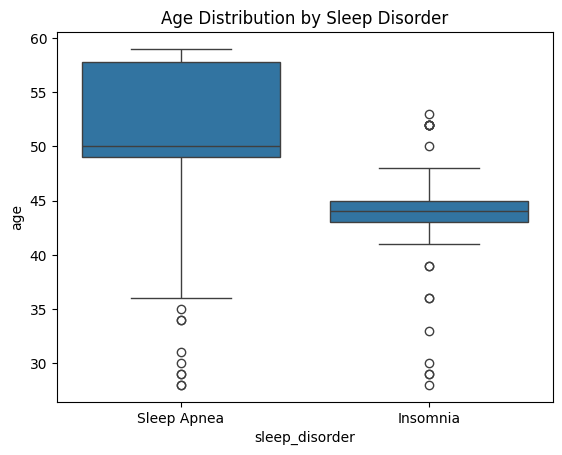

In [26]:
plt.figure()
sns.boxplot(
    x="sleep_disorder",
    y="age",
    data=df
)
plt.title("Age Distribution by Sleep Disorder")
plt.show()


In [27]:
occupation_summary = (
    df.groupby("occupation")
    .agg(
        avg_sleep_duration=("sleep_duration", "mean"),
        avg_sleep_quality=("quality_of_sleep", "mean"),
        avg_stress=("stress_level", "mean")
    )
    .sort_values("avg_sleep_quality")
)

occupation_summary


,avg_sleep_duration,avg_sleep_quality,avg_stress
occupation,,,
Sales Representative,5.900000,4.000000,8.000000
Scientist,6.000000,5.000000,7.000000
Salesperson,6.403125,6.000000,7.000000
Software Engineer,6.750000,6.500000,6.000000
Doctor,6.970423,6.647887,6.732394
Teacher,6.690000,6.975000,4.525000
Manager,6.900000,7.000000,5.000000
Nurse,7.063014,7.369863,5.547945
Accountant,7.113514,7.891892,4.594595


Occupational differences shows variation in sleep and stress patterns. Sales representative roles reveal the poorest sleep outcomes, with average sleep durations below six hours, low perceived sleep quality, and the highest stress level. In contrast, engineering and accounting roles shows the most favorable sleep profiles, longer sleep duration, higher sleep quality, and lower stress levels. These findings suggest that occupational stress and job demands play a significant role in shaping sleep health outcomes.

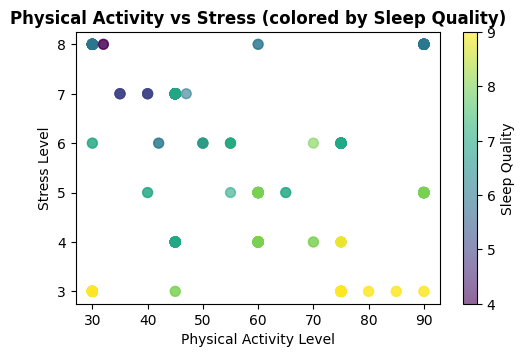

In [28]:
fig = plt.figure(figsize=(20, 12))


# Physical Activity vs Stress Level
plt.subplot(3, 3, 6)
if 'physical_activity_level' in df.columns and 'stress_level' in df.columns:
    plt.scatter(df['physical_activity_level'], df['stress_level'], 
                alpha=0.6, s=50, c=df['quality_of_sleep'], cmap='viridis')
    plt.colorbar(label='Sleep Quality')
    plt.xlabel('Physical Activity Level')
    plt.ylabel('Stress Level')
    plt.title('Physical Activity vs Stress (colored by Sleep Quality)', fontweight='bold')

stress level and physical activity level together do not show a clear pattern or correlation with sleep quality

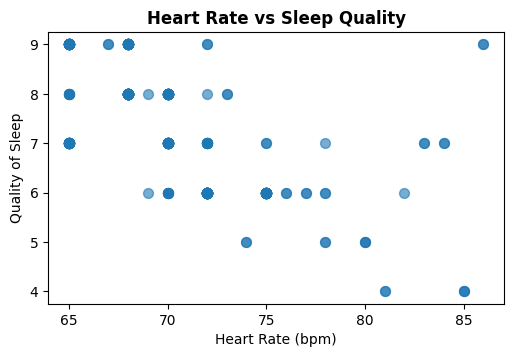

In [29]:
# Heart Rate vs Sleep Quality
fig = plt.figure(figsize=(20, 12))

plt.subplot(3, 3, 6)
if 'heart_rate' in df.columns and 'quality_of_sleep' in df.columns:
    plt.scatter(df['heart_rate'], df['quality_of_sleep'], 
                alpha=0.6, s=50)
    plt.xlabel('Heart Rate (bpm)')
    plt.ylabel('Quality of Sleep')
    plt.title('Heart Rate vs Sleep Quality', fontweight='bold')

In [30]:
corr_cols = [
    "age",
    "sleep_duration",
    "quality_of_sleep",
    "physical_activity_level",
    "stress_level",
    "heart_rate",
    "daily_steps",
    "systolic_bp",
    "diastolic_bp"
]

corr_matrix = df[corr_cols].corr()
corr_matrix


,age,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,heart_rate,daily_steps,systolic_bp,diastolic_bp
age,1.000000,0.344709,0.473734,0.178993,-0.422344,-0.225606,0.057973,0.605878,0.593839
sleep_duration,0.344709,1.000000,0.883213,0.212360,-0.811023,-0.516455,-0.039533,-0.180406,-0.166570
quality_of_sleep,0.473734,0.883213,1.000000,0.192896,-0.898752,-0.659865,0.016791,-0.121632,-0.110151
physical_activity_level,0.178993,0.212360,0.192896,1.000000,-0.034134,0.136971,0.772723,0.265416,0.382651
stress_level,-0.422344,-0.811023,-0.898752,-0.034134,1.000000,0.670026,0.186829,0.102818,0.091811
heart_rate,-0.225606,-0.516455,-0.659865,0.136971,0.670026,1.000000,-0.030309,0.294143,0.271092
daily_steps,0.057973,-0.039533,0.016791,0.772723,0.186829,-0.030309,1.000000,0.103342,0.241986
systolic_bp,0.605878,-0.180406,-0.121632,0.265416,0.102818,0.294143,0.103342,1.000000,0.972885
diastolic_bp,0.593839,-0.166570,-0.110151,0.382651,0.091811,0.271092,0.241986,0.972885,1.000000


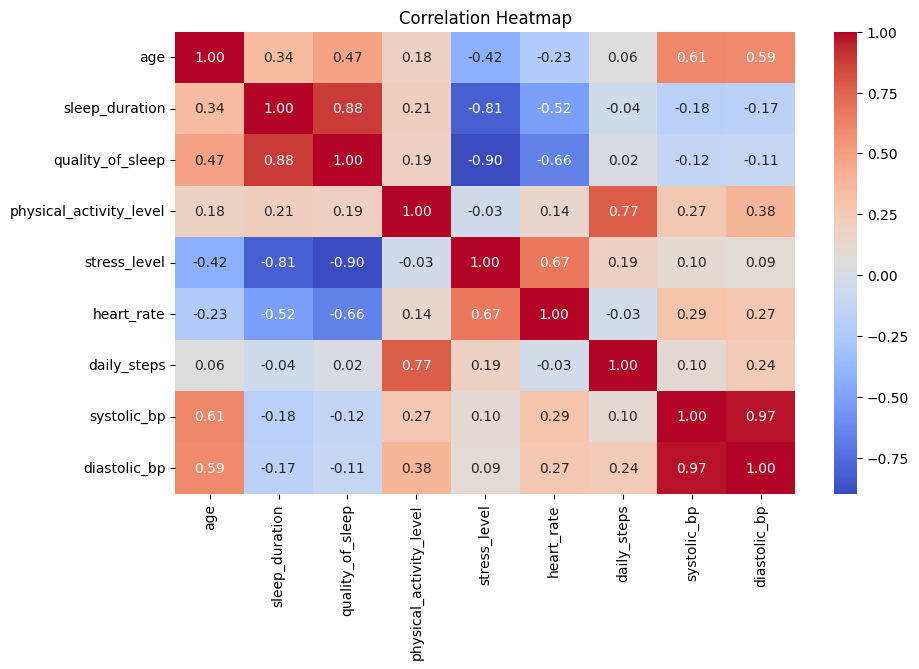

In [31]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()


RQ 1

sleep_quality categorization

In [52]:


df["sleep_quality_category"] = pd.qcut(df["quality_of_sleep"], q= 3, labels=[1, 2, 3]).astype(int)

df[["quality_of_sleep", "sleep_quality_category"]]


,quality_of_sleep,sleep_quality_category
0,6,1
1,6,1
2,6,1
3,4,1
4,4,1
...,...,...
369,9,3
370,9,3
371,9,3
372,9,3


checking for class balance

In [33]:
class_counts = df["sleep_quality_category"].value_counts()
class_percentages = df["sleep_quality_category"].value_counts(normalize=True) * 100

pd.DataFrame({
    "count": class_counts,
    "percentage (%)": class_percentages.round(2)
})


,count,percentage (%)
sleep_quality_category,,
1,194,51.87
2,109,29.14
3,71,18.98


C:\Users\ducth\AppData\Local\Temp\ipykernel_22660\3241540797.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_bin','sleep_quality_category'])
C:\Users\ducth\AppData\Local\Temp\ipykernel_22660\3241540797.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_totals = df.groupby('age_bin').size().reset_index(name='total')


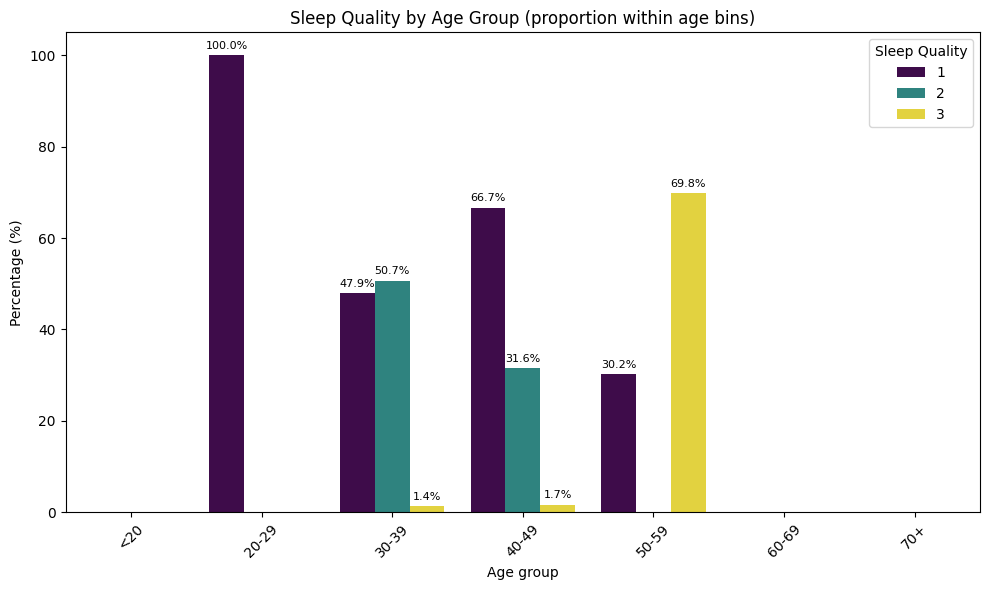

In [34]:
# Age vs Sleep quality — improved: bin ages and plot proportions
import pandas as pd
plt.figure(figsize=(10,6))

age_bins = [0,20,30,40,50,60,70,120]
age_labels = ['<20','20-29','30-39','40-49','50-59','60-69','70+']
df['age_bin'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)
# compute percent distribution of sleep-quality within each age bin
age_quality = (
    df.groupby(['age_bin','sleep_quality_category'])
      .size()
      .reset_index(name='count')
)
age_totals = df.groupby('age_bin').size().reset_index(name='total')
age_quality = age_quality.merge(age_totals, on='age_bin')
age_quality['pct'] = age_quality['count'] / age_quality['total'] * 100
# plot proportions per age bin
sns.barplot(
    x='age_bin',
    y='pct',
    hue='sleep_quality_category',
    data=age_quality,
    palette='viridis',
    order=age_labels
)
plt.ylabel('Percentage (%)')
plt.xlabel('Age group')
plt.title('Sleep Quality by Age Group (proportion within age bins)')
plt.legend(title='Sleep Quality')
plt.xticks(rotation=45)
# annotate bars with percentage labels
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x()+p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=8, xytext=(0,3), textcoords='offset points')
plt.tight_layout()
plt.show()

sanity check for categorization, if it make sense or not

In [36]:
df.groupby("sleep_quality_category")["stress_level"].mean()


sleep_quality_category
1    6.685567
2    4.605505
3    3.028169
Name: stress_level, dtype: float64

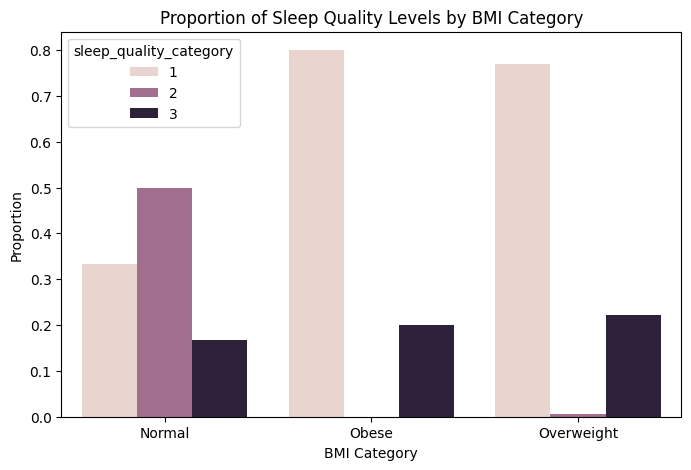

In [37]:
bmi_sleep_pct = (
    df.groupby("bmi_category")["sleep_quality_category"]
      .value_counts(normalize=True)
      .rename("percentage")
      .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x="bmi_category",
    y="percentage",
    hue="sleep_quality_category",
    data=bmi_sleep_pct
)
plt.title("Proportion of Sleep Quality Levels by BMI Category")
plt.ylabel("Proportion")
plt.xlabel("BMI Category")
plt.show()


Among people with Normal BMI, the largest share has good sleep quality, and very few have poor sleep. while among those who are Overweight, most have moderate sleep quality, with fewer having good sleep and very few poor sleep. while among those who are Obese, good sleep is less common moderate and poor sleep together make up a larger proportion. In summary, higher BMI, especially obesity shows shorter or poorer-quality sleep

## Feature selection and modeling

Feature selection

In [ ]:
X = df[
    [
        "sleep_duration",
        "physical_activity_level",
        "stress_level",
        "heart_rate",
        "daily_steps",
        "systolic_bp",
        "diastolic_bp",
        "age",
        "gender",
        "occupation",
        "bmi_category"
    ]
]

y = df["sleep_quality_category"]

X.head(), y.head()


(   sleep_duration  physical_activity_level  stress_level  heart_rate  \
 0             6.1                       42             6          77   
 1             6.2                       60             8          75   
 2             6.2                       60             8          75   
 3             5.9                       30             8          85   
 4             5.9                       30             8          85   
 
    daily_steps  systolic_bp  diastolic_bp  age gender            occupation  \
 0         4200          126            83   27   Male     Software Engineer   
 1        10000          125            80   28   Male                Doctor   
 2        10000          125            80   28   Male                Doctor   
 3         3000          140            90   28   Male  Sales Representative   
 4         3000          140            90   28   Male  Sales Representative   
 
   bmi_category  
 0   Overweight  
 1       Normal  
 2       Normal  
 3    

spliting data into train and test set and using stratified because "poor" sleep quality category is underrepresented and class ratio has to be preserve

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


(sleep_quality_category
 1    0.518395
 2    0.290970
 3    0.190635
 Name: proportion, dtype: float64,
 sleep_quality_category
 1    0.520000
 2    0.293333
 3    0.186667
 Name: proportion, dtype: float64)

encoding the categorical column using one-hot encoding, no ordinal order detected and works well with linear and tree models

standard scaler for numerical columns

In [40]:



numeric_features = [
    "physical_activity_level",
    "stress_level",
    "heart_rate",
    "daily_steps",
    "systolic_bp",
    "diastolic_bp",
    "age"
]

categorical_features = [
    "gender",
    "occupation",
    "bmi_category"
]


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)



fitting and transforming features

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape


((299, 23), (75, 23))

baseline model is logistic regression and class_weight is "balanced" this will force the "poor" sleep quality category and prevent it from ignoring

In [42]:



log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    multi_class="multinomial",
    solver="lbfgs",
    random_state=42
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", log_reg)
    ]
)


fit the model

In [43]:
model.fit(X_train, y_train)


C:\Users\ducth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


making prediction

In [44]:
y_pred = model.predict(X_test)


performance evaluation

In [45]:
accuracy = accuracy_score(y_test, y_pred)
accuracy



0.9866666666666667

In [46]:
macro_f1 = f1_score(y_test, y_pred, average="macro")
macro_f1

0.9882635882635883

In [47]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       1.00      0.97      0.99        39
           2       0.96      1.00      0.98        22
           3       1.00      1.00      1.00        14

    accuracy                           0.99        75
   macro avg       0.99      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



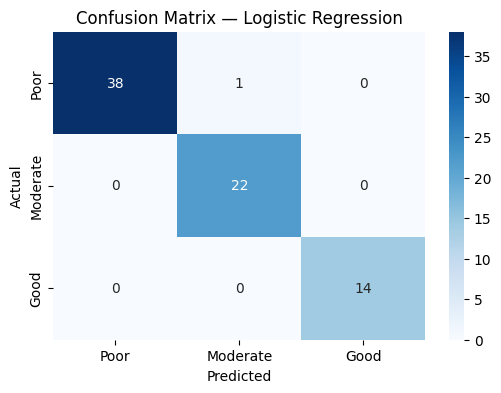

In [50]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Poor", "Moderate", "Good"],
    yticklabels=["Poor", "Moderate", "Good"],
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


In [ ]:
X.columns

Index(['sleep_duration', 'physical_activity_level', 'stress_level',
       'heart_rate', 'daily_steps', 'systolic_bp', 'diastolic_bp', 'age',
       'gender', 'occupation', 'bmi_category'],
      dtype='object')

using cross validation, stratefied kfold setup cos the dataset is small and there's need to ensure that the model isn't overfitting. Using the base model, Logistic regression 

In [ ]:

# model_str = LogisticRegression(
#     class_weight="balanced",
#     max_iter=1000,
#     random_state=42
# )





pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            multi_class="multinomial",
            solver="lbfgs",
            random_state=42
        ))
    ]
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}


cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)


C:\Users\ducth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ducth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ducth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio

In [ ]:
cv_df = pd.DataFrame(cv_results)

cv_df[[
    "train_accuracy", "test_accuracy",
    "train_macro_f1", "test_macro_f1",
    "train_weighted_f1", "test_weighted_f1"
]].mean()


train_accuracy       0.981284
test_accuracy        0.970595
train_macro_f1       0.926094
test_macro_f1        0.923949
train_weighted_f1    0.982728
test_weighted_f1     0.973120
dtype: float64

In [ ]:
pipeline.fit(X_train, y_train)

y_pred_str = pipeline.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_str))



              precision    recall  f1-score   support

        Good       1.00      1.00      1.00        36
    Moderate       1.00      1.00      1.00        37
        Poor       1.00      1.00      1.00         2

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



C:\Users\ducth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
